## Run auto tracking with SAM2Mice

In [1]:
import sys
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
import torch
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
%matplotlib inline
from PIL import Image

from SAM2_Mice.segmentation import auto_tracking_with_sam2


# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )


using device: cuda


In [2]:
import os
import gdown

# Root directory where demo data will be stored.
VIDEO_ROOT_DIR = "/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data"

dynamic_id_dir = os.path.join(VIDEO_ROOT_DIR, "4_dynamic_id")
os.makedirs(dynamic_id_dir, exist_ok=True)

video_path = os.path.join(dynamic_id_dir, "three_mice_sequence.mp4")
if not os.path.exists(video_path):
    gdown.download(
        "https://drive.google.com/uc?id=1tdZ4K87zeMluf2g7Fgr59tcWAj0IO0hC",
        video_path,
        quiet=False,
    )
    print(f"Downloaded: {video_path}")
else:
    print(f"Already exists: {video_path}")

Downloading...
From: https://drive.google.com/uc?id=1tdZ4K87zeMluf2g7Fgr59tcWAj0IO0hC
To: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence.mp4
100%|██████████| 47.6M/47.6M [00:20<00:00, 2.30MB/s]


Downloaded: /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence.mp4


In [3]:
auto_tracking_with_sam2(
    video_path=os.path.join(VIDEO_ROOT_DIR, "4_dynamic_id", "three_mice_sequence.mp4"),
    frames_dir=os.path.join(VIDEO_ROOT_DIR, "4_dynamic_id", "three_mice_sequence_frames"),
    output_dir=os.path.join(VIDEO_ROOT_DIR, "4_dynamic_id", "three_mice_sequence_seg"),
    sam2_checkpoint="../checkpoints/SAM2_Mice_base_plus.pt",
    model_cfg="../sam2/configs/sam2.1/sam2.1_hiera_b+.yaml",
    detection_ckpt_path="../checkpoints_detection/yolo11l_openfield_five_mice.pt",
    prompt_type="mask",                         # initial prompt type
    frame_step=30,                              # step size between frames
    frame_rate=10,                              # output fps
    detection_conf=0.5,                         # YOLOv11 confidence threshold
    iou_threshold=0.3,                          # for ID matching
    extract_frames=True,
    object_label="mouse",
)

Using device: cuda
Results save dir /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg
Path '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_frames' did not exist and has been created.
Path '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg' already exists.
Path '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/mask_data' did not exist and has been created.
Path '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/json_data' did not exist and has been created.
Path '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result' did not exist and has been created.


Extracting frames: 100%|██████████████████████████████████████████| 601/601 [00:07<00:00, 84.15it/s]


False


frame loading (JPEG):   1%|          | 4/601 [00:00<00:19, 30.88it/s]

Total frames: 601
Processing frame 0


...

propagate in video: 100%|██████████| 1/1 [00:00<00:00, 728.43it/s]

Processed 1 video segments
Path '/mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result' already exists.
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00000.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00001.jpg


Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00002.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00003.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00004.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00005.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00006.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00007.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/result/00008.jpg
Annotated image saved as /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dyna

100%|██████████| 601/601 [00:13<00:00, 45.54it/s]


Video saved at /mnt/nas02/LAR/pico/data_release/SAM2Mice_demo_data/4_dynamic_id/three_mice_sequence_seg/output.mp4


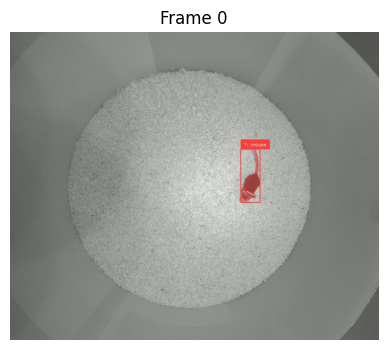

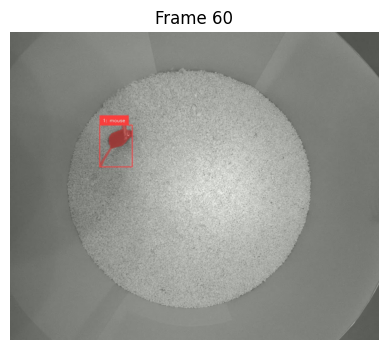

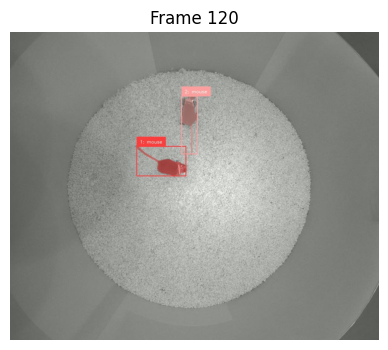

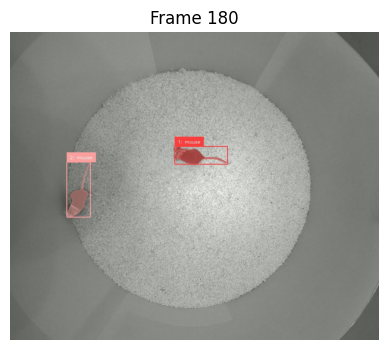

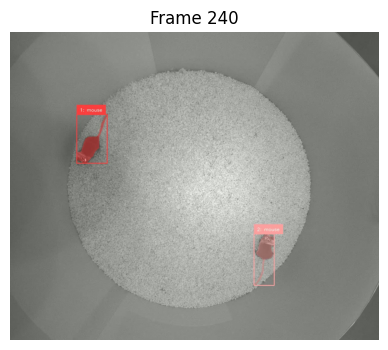

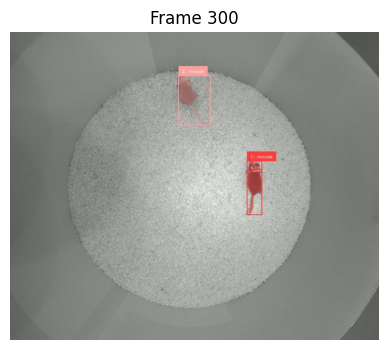

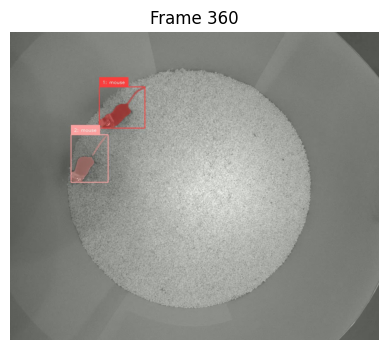

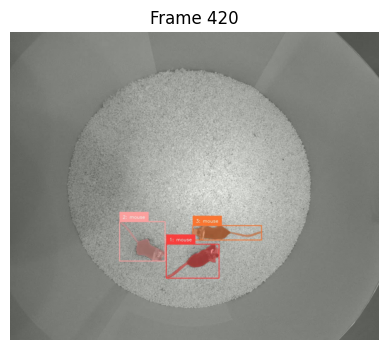

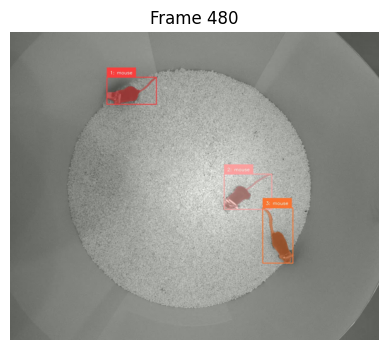

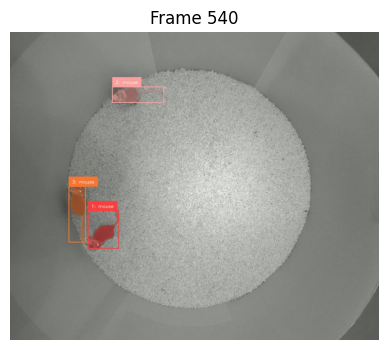

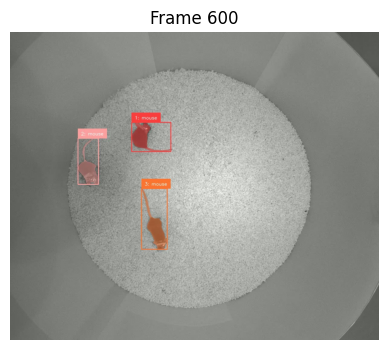

In [4]:
def show_masked_video(video_path, vis_frame_stride):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % vis_frame_stride == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(6, 4))
            plt.imshow(frame_rgb)
            plt.axis("off")
            plt.title(f"Frame {frame_idx}")
            plt.show()
            plt.close('all')

        frame_idx += 1

    cap.release()

show_masked_video(
    video_path=os.path.join(VIDEO_ROOT_DIR, "4_dynamic_id", "three_mice_sequence_seg", "output.mp4"),
    vis_frame_stride=60,
)